In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [4]:
conn= pyodbc.connect(
     "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;")
cursor = conn.cursor()
print(" successfully")

 successfully


#  Case 2 – Device Dominance & User Engagement Analysis.

## Scenario

PhonePe aims to understand user preferences across different
device brands and regions.

This analysis focuses on registered users to identify popular
device brands and important states.

## Objective

- Identify the most popular device brands.
- Identify states with the highest registered users.
- Compare user distribution across device brands.
- Identify important regions for user growth.

#### Load data

In [5]:
query2="""
select top 10 *
from aggregated_user;
"""

df2=pd.read_sql(query2, conn)
df2.head(10)

C:\Users\Devendra\AppData\Local\Temp\ipykernel_17780\3894217326.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2=pd.read_sql(query2, conn)


,States,Years,Quarter,Brands,Transaction_count,Percentage
0,Andaman & Nicobar,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar,2018,1,OnePlus,332,0.049258
5,Andaman & Nicobar,2018,1,Realme,316,0.046884
6,Andaman & Nicobar,2018,1,Apple,229,0.033976
7,Andaman & Nicobar,2018,1,Motorola,226,0.033531
8,Andaman & Nicobar,2018,1,Lenovo,202,0.029970
9,Andaman & Nicobar,2018,1,Huawei,158,0.023442


In [11]:
df2["Brands"].unique()

<ArrowStringArray>
[  'Xiaomi',  'Samsung',     'Vivo',     'Oppo',  'OnePlus',   'Realme',
    'Apple', 'Motorola',   'Lenovo',   'Huawei']
Length: 10, dtype: str

# Top 10 States by Users


C:\Users\Devendra\AppData\Local\Temp\ipykernel_17780\93925040.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_state = pd.read_sql(query, conn)


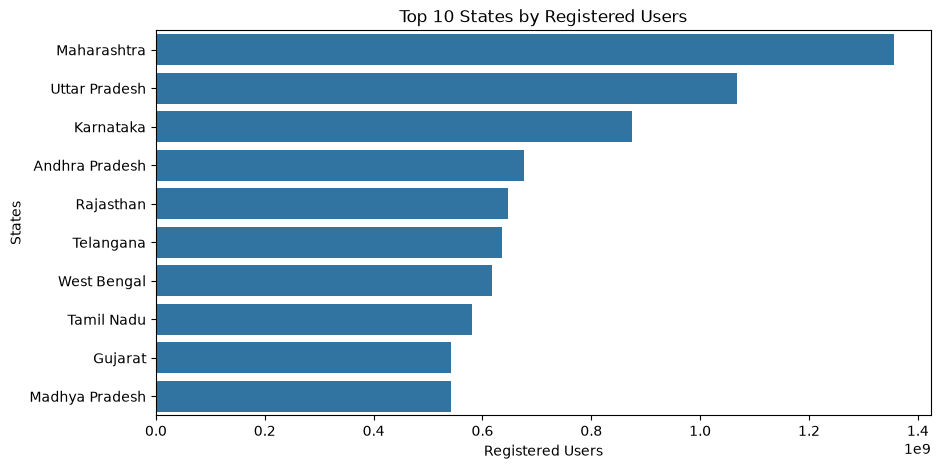

In [6]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY States
ORDER BY Total_Users DESC
"""

df_state = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_state, x="Total_Users", y="States")

plt.title("Top 10 States by Registered Users")
plt.xlabel("Registered Users")
plt.ylabel("States")
plt.show()

### which states have the most registered PhonePe users

# Device Brand Distribution

C:\Users\Devendra\AppData\Local\Temp\ipykernel_17780\2419029489.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_brand = pd.read_sql(query, conn)


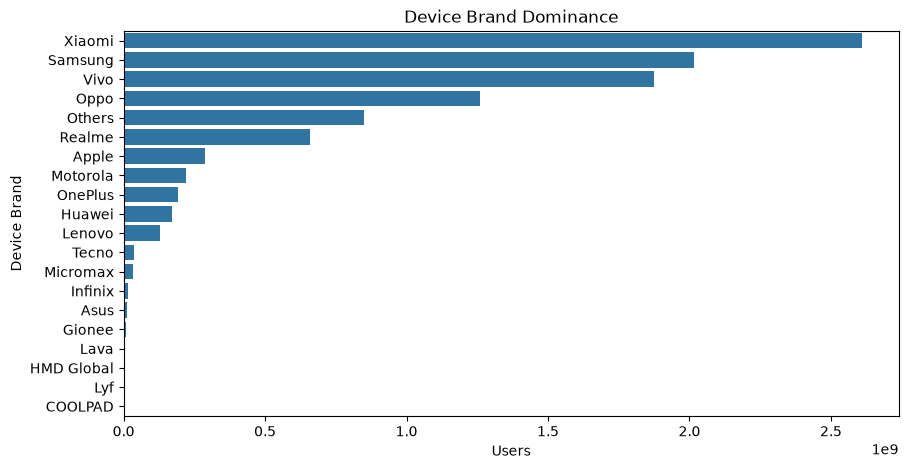

In [7]:
query = """
SELECT
    Brands,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY Brands
ORDER BY Total_Users DESC
"""

df_brand = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_brand, x="Total_Users", y="Brands")

plt.title("Device Brand Dominance")
plt.xlabel("Users")
plt.ylabel("Device Brand")
plt.show()

#### which mobile brands are most commonly used by PhonePe users.

###

### Device Usage by State

C:\Users\Devendra\AppData\Local\Temp\ipykernel_20248\3378223301.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_device = pd.read_sql(query, conn)


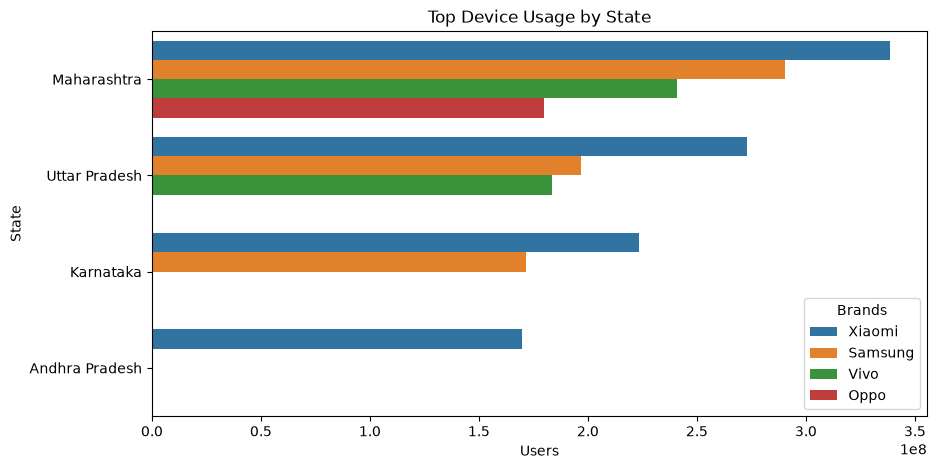

In [15]:
query = """
SELECT
    States,
    Brands,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY States, Brands
ORDER BY Total_Users DESC
"""

df_device = pd.read_sql(query, conn)

top10 = df_device.head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="Total_Users", y="States", hue="Brands")

plt.title("Top Device Usage by State")
plt.xlabel("Users")
plt.ylabel("State")
plt.show()

#### Shows which device brands are popular in different states.

### Conclusion

TPhonePe user engagement varies across states and device brands. A few states and device brands have a higher user base, while some devices are underutilized. PhonePe can improve app performance by prioritizing popular devices and use state-wise device trends to create targeted marketing campaigns and offers

PhonePe should optimize app performance for popular devices and use state-wise device data to create targeted offers and improve user engagement